# Prompt

We will create a notebook that creates simulated data for a financial app. 

The data will be related to user behaviour: account creation, sessions, and transactions. We will start the simulation at 1/1/2026 and run until 21/2/2026. 

The data is stored in the following tables: 
- Accounts [user-id, creation-date, session-prob, transaction-prob]
- Sessions [user-id, session-id, login-timestamp]
- Transaction [session-id, transaction-id]

Then, we will simulate each day by iterating through existing accounts, and creating new ones, then checking according to parameters if they have sessions or transactions. 

These are the parameters: 
- We start with 1000 accounts created at 1/1 
- Each day we create new accounts from a poisson distribution with parameter=10 
- Each day we increase the new accounts parameter by 2%
- Each account when created gets a session probability and a transaction probability parameter. 
- Session probability and transaction probabilities come from a normal distribution with mean 0.2 and std 0.05

This is the simulation loop:
- Every day we create new accounts according to the new account distribution, and add them to the accounts table. These accounts are assigned session and transaction probabilities
- Every day we check if each account has a session and add it to the sessions table. 
- If an account has a session, we check if it has a transaction, and add it to the transactions table. 

After the simulation, let's create a few plots, showing number of accounts, number of sessions and number of transactions. 

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

# Date range: 1/1/2026 to 21/2/2026
start_date = datetime(2026, 1, 1)
end_date = datetime(2026, 2, 21)
days = (end_date - start_date).days + 1
date_list = [start_date + timedelta(d) for d in range(days)]

def clip_prob(p):
    return np.clip(p, 0.0, 1.0)

# Initialize tables
accounts = []   # [user_id, creation_date, session_prob, transaction_prob]
sessions = []   # [user_id, session_id, login_timestamp]
transactions = []  # [session_id, transaction_id]

user_id_counter = 0
session_id_counter = 0
transaction_id_counter = 0

# Initial 1000 accounts on 1/1/2026
n_initial = 1000
for _ in range(n_initial):
    user_id_counter += 1
    session_prob = clip_prob(np.random.normal(0.2, 0.05))
    transaction_prob = clip_prob(np.random.normal(0.2, 0.05))
    accounts.append({
        'user_id': user_id_counter,
        'creation_date': start_date,
        'session_prob': session_prob,
        'transaction_prob': transaction_prob
    })

# Daily new-accounts parameter: start 10, increase 2% per day
lambda_new_accounts = 10.0
growth = 1.02

In [2]:
# Simulation loop: for each day
for d, current_date in enumerate(date_list):
    # 1. Create new accounts (Poisson) and add to accounts table
    n_new = np.random.poisson(lambda_new_accounts)
    for _ in range(n_new):
        user_id_counter += 1
        session_prob = clip_prob(np.random.normal(0.2, 0.05))
        transaction_prob = clip_prob(np.random.normal(0.2, 0.05))
        accounts.append({
            'user_id': user_id_counter,
            'creation_date': current_date,
            'session_prob': session_prob,
            'transaction_prob': transaction_prob
        })
    # Increase lambda by 2% for next day
    lambda_new_accounts *= growth

    # 2. For each account that exists on or before this day, decide session then transaction
    for acc in accounts:
        if acc['creation_date'] > current_date:
            continue
        if np.random.random() < acc['session_prob']:
            session_id_counter += 1
            # Login timestamp: use current day (e.g. noon for simplicity)
            login_ts = current_date.replace(hour=12, minute=0, second=0, microsecond=0)
            sessions.append({
                'user_id': acc['user_id'],
                'session_id': session_id_counter,
                'login_timestamp': login_ts
            })
            if np.random.random() < acc['transaction_prob']:
                transaction_id_counter += 1
                transactions.append({
                    'session_id': session_id_counter,
                    'transaction_id': transaction_id_counter
                })

print('Simulation done.')
print('Accounts:', len(accounts))
print('Sessions:', len(sessions))
print('Transactions:', len(transactions))

Simulation done.
Accounts: 1933
Sessions: 14432
Transactions: 2939


In [3]:
# Build DataFrames
df_accounts = pd.DataFrame(accounts)
df_sessions = pd.DataFrame(sessions)
df_transactions = pd.DataFrame(transactions)

# Daily aggregates for plotting
daily_accounts = df_accounts.groupby('creation_date').size().reindex(pd.DatetimeIndex(date_list), fill_value=0)
daily_accounts_cum = daily_accounts.cumsum()
# Sessions and transactions by login/creation date
sessions_by_date = df_sessions.set_index('login_timestamp').resample('D').size().reindex(pd.DatetimeIndex(date_list), fill_value=0)
# Transactions: join to sessions to get date
tx_with_date = df_transactions.merge(df_sessions[['session_id', 'login_timestamp']], on='session_id')
tx_by_date = tx_with_date.set_index('login_timestamp').resample('D').size().reindex(pd.DatetimeIndex(date_list), fill_value=0)

display(df_accounts.head(), df_sessions.head(), df_transactions.head())

,user_id,creation_date,session_prob,transaction_prob
0,1,2026-01-01,0.224836,0.193087
1,2,2026-01-01,0.232384,0.276151
2,3,2026-01-01,0.188292,0.188293
3,4,2026-01-01,0.278961,0.238372
4,5,2026-01-01,0.176526,0.227128


,user_id,session_id,login_timestamp
0,5,1,2026-01-01 12:00:00
1,10,2,2026-01-01 12:00:00
2,11,3,2026-01-01 12:00:00
3,16,4,2026-01-01 12:00:00
4,22,5,2026-01-01 12:00:00


,session_id,transaction_id
0,12,1
1,18,2
2,20,3
3,22,4
4,30,5


In [7]:
df_accounts[['user_id', 'creation_date']].to_csv('df_accounts.csv', index=True)
df_sessions.to_csv('df_sessions.csv', index=True)
df_transactions.to_csv('df_transactions.csv', index=True)

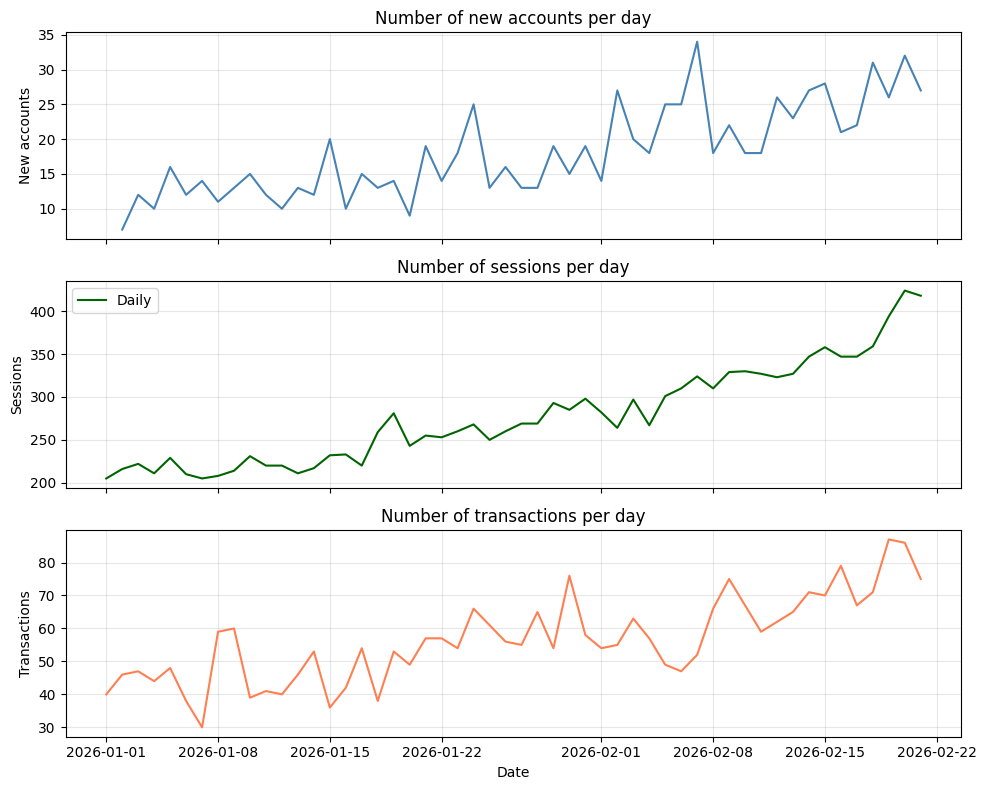

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# 1. Number of new accounts daily (NOT cumulative)
axes[0].plot(date_list[1:], daily_accounts.values[1:], color='steelblue')
axes[0].set_ylabel('New accounts')
axes[0].set_title('Number of new accounts per day')
axes[0].grid(True, alpha=0.3)

# 2. Number of sessions per day (NOT cumulative)
axes[1].plot(date_list, sessions_by_date.values, color='darkgreen', label='Daily')
axes[1].set_ylabel('Sessions')
axes[1].set_title('Number of sessions per day')
axes[1].grid(True, alpha=0.3)

# 3. Number of transactions per day (NOT cumulative)
axes[2].plot(date_list, tx_by_date.values, color='coral')
axes[2].set_ylabel('Transactions')
axes[2].set_xlabel('Date')
axes[2].set_title('Number of transactions per day')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

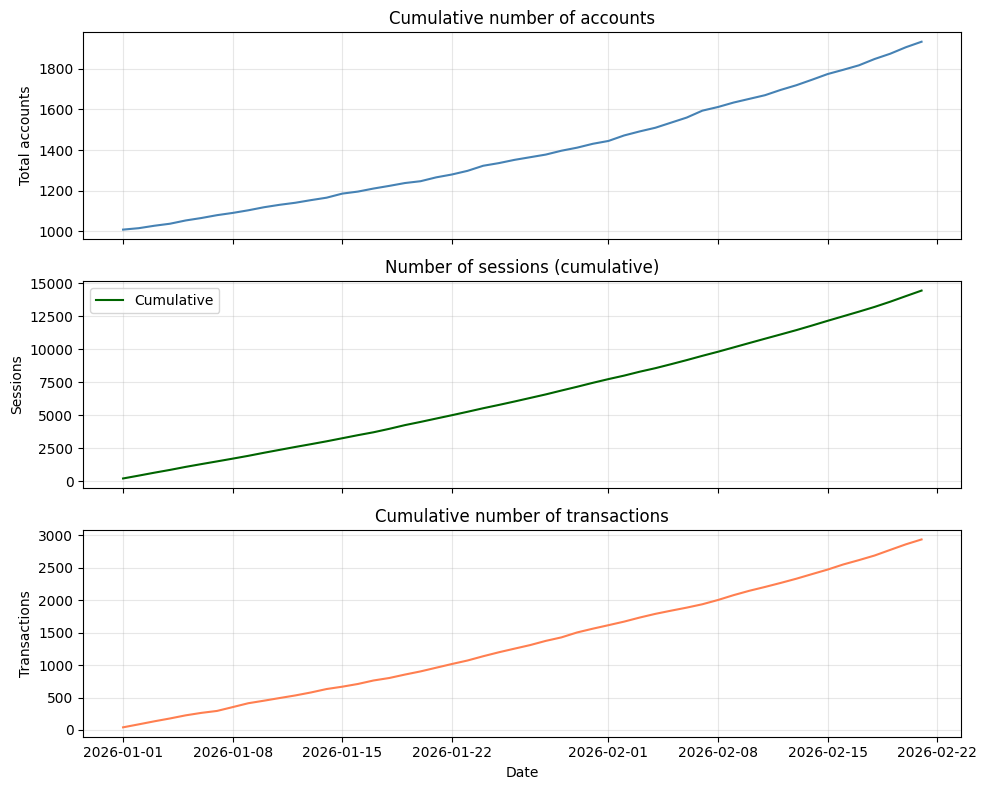

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# 1. Number of accounts (cumulative)
axes[0].plot(date_list, daily_accounts_cum.values, color='steelblue')
axes[0].set_ylabel('Total accounts')
axes[0].set_title('Cumulative number of accounts')
axes[0].grid(True, alpha=0.3)

# 2. Number of sessions (cumulative)
sessions_cum = sessions_by_date.cumsum()
axes[1].plot(date_list, sessions_cum.values, color='darkgreen', label='Cumulative')
axes[1].set_ylabel('Sessions')
axes[1].set_title('Number of sessions (cumulative)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Number of transactions (cumulative)
tx_cum = tx_by_date.cumsum()
axes[2].plot(date_list, tx_cum.values, color='coral')
axes[2].set_ylabel('Transactions')
axes[2].set_xlabel('Date')
axes[2].set_title('Cumulative number of transactions')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()